In [2]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random

from tqdm import tqdm

# Домашнее задание 4 - Непараметрические критерии


##Задача 1

1.   Сгенерить самостоятельно 2 распределения, нормальное с любыми параметрами и размером 1000 и биномиальное с параметрами 1, 0.5 и размером 100
2.   Для каждого распределения
    *   Построить Q-Q plot
    *   Проверить нормальность с помощью критерия согласия Колмогорова
    *   Проверить нормальность с помощью критерия Шапиро-Уилка
    *   Проверить то что ваши распределения имееют общее распределение с помощью критерия однородности Смирнова
3.   Собрать новую выборку из ваших 2 сгенирированных распределений. Для этого взять случайных 900 элементов из нормального распределения и добавить к ним выборку с биномиальным распределением, чтобы снова получили выборки из 1000 элементов
4.   Для новой "собранной выборки"
    *   Построить Q-Q plot
    *   Проверить нормальность с помощью критерия согласия Колмогорова
    *   Проверить нормальность с помощью критерия Шапиро-Уилка
5.  Из выборки с нормальным распределением получить новую выборку. Сделаем это с помощью "докидывания эффекта". Взять текущую выборку с нормальным распределением и рандомные 500 элементов увеличить на 5%, остальные оставим без изменений
6. Для новой выборки с "докинутым эффектом"
    *   Построить Q-Q plot
    *   Проверить нормальность с помощью критерия согласия Колмогорова
    *   Проверить нормальность с помощью критерия Шапиро-Уилка
    *   Проверить то что ваши распределения(изначальное нормальное из п1 и полученное в п5) имееют общее распределение с помощью критерия однородности Смирнова


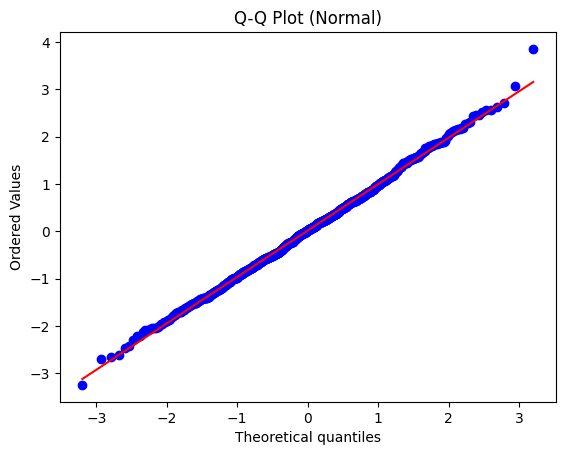

Kolmogorov-Smirnov test for Normal: KstestResult(statistic=np.float64(0.017327787320720822), pvalue=np.float64(0.9196626608357358), statistic_location=np.float64(-0.07444591576616721), statistic_sign=np.int8(-1))
Shapiro-Wilk test for Normal: ShapiroResult(statistic=np.float64(0.9986092190571166), pvalue=np.float64(0.6272578290249117))


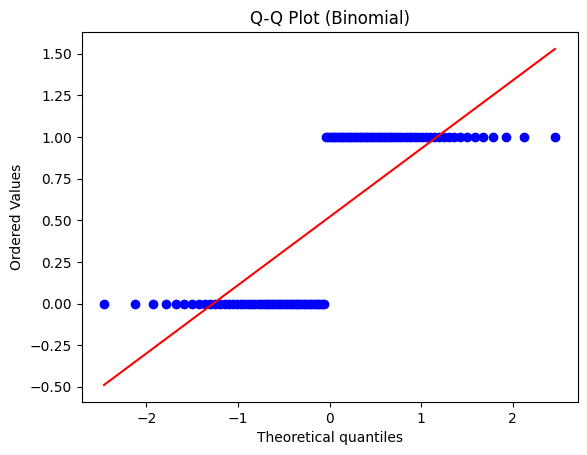

Kolmogorov-Smirnov test for Binomial: KstestResult(statistic=np.float64(0.5), pvalue=np.float64(1.213143437181786e-23), statistic_location=np.int32(0), statistic_sign=np.int8(-1))
Shapiro-Wilk test for Binomial: ShapiroResult(statistic=np.float64(0.6358192863457472), pvalue=np.float64(2.1735753688912464e-14))
Smirnov test (normal vs binomial): KstestResult(statistic=np.float64(0.49), pvalue=np.float64(1.6472123718765566e-20), statistic_location=np.float64(-0.0036025390905684044), statistic_sign=np.int8(1))


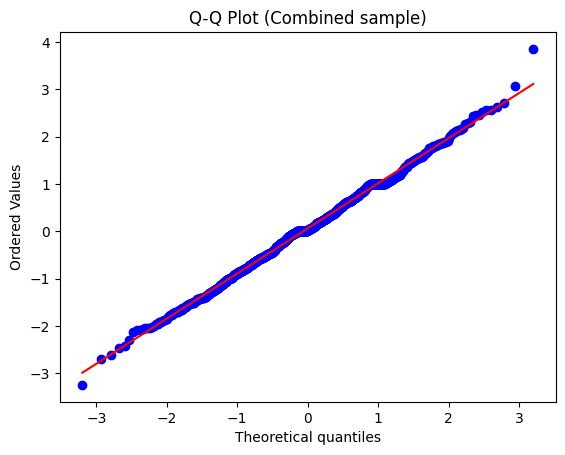

Kolmogorov-Smirnov test for Combined sample: KstestResult(statistic=np.float64(0.06532778732072081), pvalue=np.float64(0.00037368013902004774), statistic_location=np.float64(-0.07444591576616721), statistic_sign=np.int8(-1))
Shapiro-Wilk test for Combined sample: ShapiroResult(statistic=np.float64(0.9976016591153286), pvalue=np.float64(0.15272166371457074))


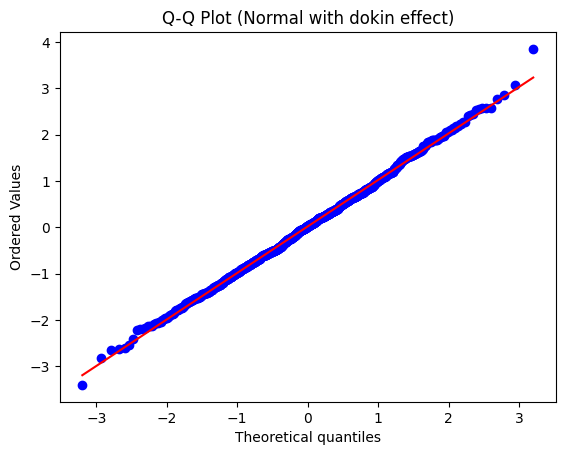

Kolmogorov-Smirnov test for Normal with dokin effect: KstestResult(statistic=np.float64(0.01761558702480215), pvalue=np.float64(0.9100326257283958), statistic_location=np.float64(1.4729340264829043), statistic_sign=np.int8(-1))
Shapiro-Wilk test for Normal with dokin effect: ShapiroResult(statistic=np.float64(0.9987116159424233), pvalue=np.float64(0.6963696362737204))
Smirnov test (original vs dokin): KstestResult(statistic=np.float64(0.011), pvalue=np.float64(0.9999999867571524), statistic_location=np.float64(0.6339190223180112), statistic_sign=np.int8(1))


In [3]:
np.random.seed(42)

norm_sample = np.random.normal(loc=0, scale=1, size=1000)
binom_sample = np.random.binomial(n=1, p=0.5, size=100)

def check_distribution(sample, name):
    stats.probplot(sample, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot ({name})")
    plt.show()
    print(f"Kolmogorov-Smirnov test for {name}:", stats.kstest(sample, 'norm'))
    print(f"Shapiro-Wilk test for {name}:", stats.shapiro(sample))

check_distribution(norm_sample, "Normal")
check_distribution(binom_sample, "Binomial")
print("Smirnov test (normal vs binomial):", stats.ks_2samp(norm_sample, binom_sample))

combined_sample = np.concatenate([np.random.choice(norm_sample, 900, replace=False),
                                  np.random.choice(binom_sample, 100, replace=True)])
check_distribution(combined_sample, "Combined sample")

dokin_sample = norm_sample.copy()
indices = np.random.choice(len(dokin_sample), 500, replace=False)
dokin_sample[indices] *= 1.05
check_distribution(dokin_sample, "Normal with dokin effect")

print("Smirnov test (original vs dokin):", stats.ks_2samp(norm_sample, dokin_sample))


## Задача 2

Для данных из файла employees.xls постройте гистограмму для переменной SALARY. Проверьте нормальность этих данных с помощью:
  * Q-Q plot
  * Критерия Колмогорова
  * Критерия Шапиро-Уилка

In [4]:
!curl -O https://raw.githubusercontent.com/YuriyKotov/datasets/master/employees.xls >> employees.xls

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0 26624    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0Warning: Failed to open the file employees.xls: Permission denied

  0 26624    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
curl: (23) client returned ERROR on write of 1371 bytes


In [4]:
import pandas as pd

df = pd.read_excel('employees.xls').rename(columns={'Unnamed: 0': 'NAME'})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   NAME      100 non-null    object
 1   GENDER    100 non-null    object
 2   DEPART    100 non-null    object
 3   EDUC      100 non-null    object
 4   AGE       100 non-null    int64 
 5   HEIGHT    100 non-null    int64 
 6   SENIOR    100 non-null    int64 
 7   SALARY    100 non-null    int64 
 8   INI_PROF  100 non-null    int64 
 9   CUR_PROF  100 non-null    int64 
dtypes: int64(6), object(4)
memory usage: 7.9+ KB


In [5]:
df.head()

,NAME,GENDER,DEPART,EDUC,AGE,HEIGHT,SENIOR,SALARY,INI_PROF,CUR_PROF
0,Alexander,Female,Ship,College,22,63,4,23400,82,90
1,Arcones,Male,Package,College,49,65,17,40400,89,123
2,Barber,Male,Bake,College,36,67,8,29400,77,93
3,Barrera,Male,Package,HS,37,67,3,24800,102,108
4,Bester,Male,Ship,Grad,43,66,11,31200,82,104


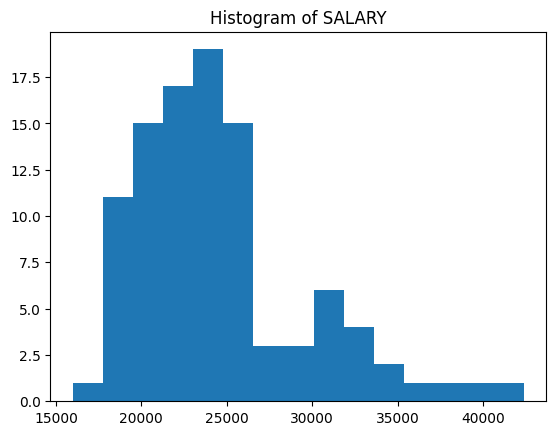

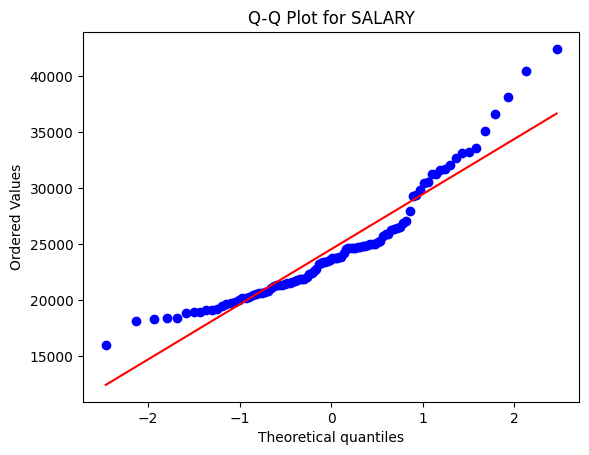

Kolmogorov-Smirnov test: KstestResult(statistic=np.float64(0.1527059097996457), pvalue=np.float64(0.016788206379648063), statistic_location=np.int64(25000), statistic_sign=np.int8(1))
Shapiro-Wilk test: ShapiroResult(statistic=np.float64(0.9015022004875934), pvalue=np.float64(1.6646450285980571e-06))


In [8]:
df = pd.read_excel('employees.xls').rename(columns={'Unnamed: 0': 'NAME'})
salary = df['SALARY']

plt.hist(salary, bins=15)
plt.title("Histogram of SALARY")
plt.show()

stats.probplot(salary, dist="norm", plot=plt)
plt.title("Q-Q Plot for SALARY")
plt.show()

print("Kolmogorov-Smirnov test:", stats.kstest(salary, 'norm', args=(salary.mean(), salary.std())))
print("Shapiro-Wilk test:", stats.shapiro(salary))


## Задача 3

Для данных из файла employees.xls проверить с помощью критерия знаков и рангового критерия гипотезу что медианная зарплата равна 25000

In [10]:
from statsmodels.stats.descriptivestats import sign_test

hypothesized_median = 25000
salary_data = df['SALARY']

stat, p_value = sign_test(salary_data, mu0=hypothesized_median)

print(f"Sign test statistic = {stat:.4f}")
print(f"p-value = {p_value:.5f}")

alpha = 0.05
if p_value < alpha:
    print("Гипотеза о медиане = 25000 отклоняется.")
else:
    print("Нет оснований отклонять гипотезу: медиана ≈ 25000.")

Sign test statistic = -17.5000
p-value = 0.00049
Гипотеза о медиане = 25000 отклоняется.


## Задача 4

В файле anorexia.txt записан вес пациентов до и после начала терапии от анорексии. С помощью критерия знаков и рангового критерия проверить, была ли эффективна данная терапия

In [16]:
!curl -O https://raw.githubusercontent.com/YuriyKotov/datasets/master/anorexia.txt >> anorexia.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0Warning: Failed to open the file anorexia.txt: Permission denied

  0   355    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
curl: (23) client returned ERROR on write of 355 bytes


In [18]:
df = pd.read_csv('anorexia.txt', sep='\t')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Before  29 non-null     float64
 1   After   29 non-null     float64
dtypes: float64(2)
memory usage: 596.0 bytes


In [19]:
df.head()

,Before,After
0,80.5,82.2
1,84.9,85.6
2,81.5,81.4
3,82.6,81.9
4,79.9,76.4


In [21]:
from statsmodels.stats.descriptivestats import sign_test
from scipy import stats

before = df['Before']
after = df['After']

diff = after - before

stat_sign, p_sign = sign_test(diff)
print(f"Sign test: statistic = {stat_sign:.4f}, p-value = {p_sign:.5f}")

# --- Критерий Вилкоксона ---
stat_wilcoxon, p_wilcoxon = stats.wilcoxon(before, after, alternative='two-sided')
print(f"Wilcoxon test: statistic = {stat_wilcoxon:.4f}, p-value = {p_wilcoxon:.5f}")

# --- Интерпретация ---
alpha = 0.05
if p_wilcoxon < alpha:
    print("\nВывод: p-value < 0.05 → терапия оказала статистически значимый эффект (вес изменился).")
else:
    print("\nВывод: p-value > 0.05 → терапия не показала статистически значимого эффекта.")


Sign test: statistic = 3.5000, p-value = 0.26493
Wilcoxon test: statistic = 131.5000, p-value = 0.06292

Вывод: p-value > 0.05 → терапия не показала статистически значимого эффекта.


## Задача 5

В файле seattle.txt записаны цены на объекты недвижимости в одном районе из районов Сиетла в 2001 и 2002 году (объекты выбирались случайно). Изменились ли средние цены в этом районе за год? Проверить это с помощью рангового критерия

In [11]:
!curl -O https://raw.githubusercontent.com/YuriyKotov/datasets/master/seattle.txt >> seattle.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0Warning: Failed to open the file seattle.txt: Permission denied

  0   996    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
curl: (23) client returned ERROR on write of 996 bytes


In [ ]:
df = pd.read_csv('seattle.txt', sep='\t')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   100 non-null    float64
 1   Year    100 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 1.7 KB


In [ ]:
df.head()

,Price,Year
0,142.0,2002
1,232.0,2002
2,132.5,2002
3,200.0,2002
4,362.0,2002


In [ ]:
# Решение

## Задача 6

В рамках исследования эффективности лекарства
пациенты с синдромом дефицита внимания и гиперактивностью в течение недели принимали либо лекарство, либо плацебо. В конце недели каждый пациент проходил тест на способность к подавлению импульсивных поведенческих реакций. Был ли эффект от применения лекарства? Данные находятся в файле methylphenidate.txt.

In [12]:
!curl -O https://raw.githubusercontent.com/YuriyKotov/datasets/master/methylphenidate.txt >> methylphenidate.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0Warning: Failed to open the file methylphenidate.txt: Permission denied

  0   168    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
curl: (23) client returned ERROR on write of 168 bytes


In [ ]:
df = pd.read_csv('methylphenidate.txt', sep=' ')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Placebo          24 non-null     int64
 1   Methylphenidate  24 non-null     int64
dtypes: int64(2)
memory usage: 516.0 bytes


In [ ]:
df.head()

,Placebo,Methylphenidate
0,57,62
1,27,49
2,32,30
3,31,34
4,34,38


In [ ]:
# Решение

## Задача 7


1.   Сгенерировать выборки с нормальным распределением без выбросов, докинуть эффект на одну из них равномерно и с помощью распределения
2.   То же, что и в п1, но выборки с выбросами сделать
3.   Для случаев из п1 и п2 бутстрэпом оценить: среднее, медиану, 25% перцентиль, построить доверительные интервалы для статистик (речь о разницах средних/медиан/перцентилей для групп)
4.   Для случаев из п1 и п2 оценить среднее т-тестом и Манном-Уитни. Сравнить с результатами бутстрэпа. Сделать выводы. Сравниваем точечные оценки (на бутстрэпе их тоже считаем)

Примечание:
- Бутстреп считать минимум на 1000 итераций
- Для докидывания эффекта с помощью распределения возьмите распределение из stats, параметры задаются исходя из параметров изначального вектора и желаемого эффекта

In [ ]:
# 1

n_samples = 1000
mean = 0
std_dev = 1

sample1 = np.random.normal(loc=mean, scale=std_dev, size=n_samples)

sample2 = np.random.normal(loc=mean, scale=std_dev, size=n_samples) * 1.05 # докинули эффект равномерно

effect_normal = np.random.normal(loc=2, scale=0.5, size=n_samples)
sample3 = np.random.normal(loc=mean, scale=std_dev, size=n_samples) + effect_normal # докинули эффект с помощью распределения

In [ ]:
# 2

# Докидываем выбросы из сгенерированных данных из равномерного распределения
# Особо не играет роли как докидывать выборосы, можно хоть вручную добавить
sample4 = np.copy(sample1)
sample4[np.random.choice(n_samples, size=50, replace=False)] = np.random.uniform(low=10, high=15, size=50)

sample5 = np.copy(sample2)
sample5[np.random.choice(n_samples, size=50, replace=False)] = ...

sample6 = np.copy(sample3)
sample6[np.random.choice(n_samples, size=50, replace=False)] = ...

In [ ]:
# Решение

## Задача 8*

Сгенерировать 2 выборки из нормального распределения с 1000 элементов каждая.
- Оцените на этих данных мощность и корректность t-test и Манна-Уитни
- Докиньте выбросы в обе группы и проверьте как изменится мощность и корректность

Для оценки использовать минимум 1000 итераций

In [ ]:
n_samples = 1000
n_iterations = 10000
alpha = 0.05

print("Мощность - вероятность найти статзначимые изменения там где они реально есть")
print("Корректность (1-alpha) - вероятность найти статзначимые изменения там где их нет")

Мощность - вероятность найти статзначимые изменения там где они реально есть
Корректность (1-alpha) - вероятность найти статзначимые изменения там где их нет


In [ ]:
# Решение